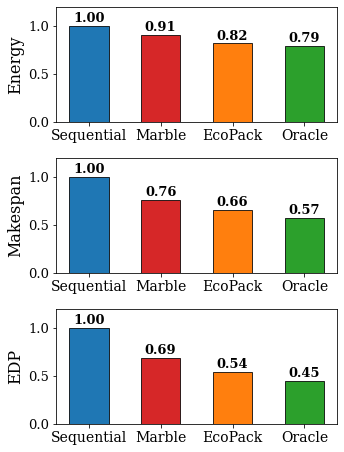

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 13,
})

policies = ['Sequential', 'Marble', 'EcoPack','Oracle']
energy_kj = [250.39, 228.51, 205.60, 198.27]
makespan_s = [372.14, 282.31, 245.40, 212.23]
edp = [e * m for e, m in zip(energy_kj, makespan_s)]

colors = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c']

# Normalize all to Sequential = 1
data = [energy_kj, makespan_s, edp]
ylabels = ['Energy', 'Makespan', 'EDP']
normed = [[v / d[0] for v in d] for d in data]

fig, axes = plt.subplots(3, 1, figsize=(5, 6.5))

for ax, vals, ylabel in zip(axes, normed, ylabels):
    bars = ax.bar(policies, vals, color=colors, edgecolor='black',
                  linewidth=0.8, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.2)

plt.tight_layout()
plt.savefig('../fig/energy_makespan_edp_comparison.png', dpi=300)
plt.show()